In [1]:
import os
import sys

# 현재 작업 디렉토리 확인해보고
print("CWD:", os.getcwd())

# notebooks/ 에서 한 단계 위(프로젝트 루트)로 올라가기
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("PROJECT_ROOT:", PROJECT_ROOT)

# sys.path 에 프로젝트 루트가 없으면 추가
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path")


CWD: c:\Users\user\Desktop\project\scalp-vision-agent\notebooks
PROJECT_ROOT: c:\Users\user\Desktop\project\scalp-vision-agent
Added to sys.path


In [2]:
import torch
from torch.utils.data import DataLoader
from torch import optim

from src.config import MASTER_INDEX_CSV
from src.cnn.dataset import ScalpDataset
from src.cnn.models import MultiHeadResNet18
from src.cnn.utils import labels_dict_to_tensor
from src.cnn.losses import multihead_ce_loss
from src.cnn.train import get_device, train_one_epoch, evaluate_one_epoch, train_model


In [3]:
device = get_device()
device


device(type='cuda')

In [4]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4


In [5]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
    ),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])


In [6]:
from torch.utils.data import Subset

train_dataset = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="train", transforms=train_transform)
val_dataset   = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="val",   transforms=val_transform)

print(len(train_dataset), len(val_dataset))


67588 23568


In [7]:
USE_SUBSET = False   # overfit 테스트: True, 전체 학습: False

if USE_SUBSET:
    subset_indices = list(range(100))  
    train_dataset_small = Subset(train_dataset, subset_indices)
    train_loader = DataLoader(train_dataset_small, batch_size=BATCH_SIZE, shuffle=True)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [8]:
model = MultiHeadResNet18()
model.to(device)

from torch.optim import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=LR,           # 기존 lr 그대로 (너가 쓰던 값)
    weight_decay=1e-4, # 새로 추가
)


In [9]:
batch = next(iter(train_loader))

print("type:", type(batch["image"]))
print("shape:", batch["image"].shape)
print("dtype:", batch["image"].dtype)
print("device:", batch["image"].device)


type: <class 'torch.Tensor'>
shape: torch.Size([32, 3, 224, 224])
dtype: torch.float32
device: cpu


In [10]:
len(train_dataset), len(train_loader), len(val_dataset), len(val_loader)


(67588, 2113, 23568, 737)

In [11]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_epochs=10,
    device=device,
    best_model_path="models/02.multihead_resnet18_best.pth",
    last_model_path="models/02.multihead_resnet18_last.pth",
)


  ↳ Best model updated! val_loss=0.6187
[01] train_loss=0.6540, train_acc=0.7333 | val_loss=0.6187, val_acc=0.7465time=55:24 (3324.9s)
  ↳ Best model updated! val_loss=0.5997
[02] train_loss=0.6101, train_acc=0.7518 | val_loss=0.5997, val_acc=0.7522time=57:08 (3428.9s)
  ↳ Best model updated! val_loss=0.5767
[03] train_loss=0.5957, train_acc=0.7571 | val_loss=0.5767, val_acc=0.7637time=55:27 (3327.7s)
[04] train_loss=0.5834, train_acc=0.7622 | val_loss=0.6615, val_acc=0.7258time=55:27 (3327.9s)
[05] train_loss=0.5730, train_acc=0.7663 | val_loss=0.5980, val_acc=0.7536time=55:33 (3333.5s)
[06] train_loss=0.5624, train_acc=0.7702 | val_loss=0.6225, val_acc=0.7461time=55:30 (3330.9s)
[07] train_loss=0.5488, train_acc=0.7754 | val_loss=0.6139, val_acc=0.7469time=55:40 (3341.0s)
[08] train_loss=0.5358, train_acc=0.7810 | val_loss=0.5938, val_acc=0.7626time=55:40 (3341.0s)
[09] train_loss=0.5208, train_acc=0.7874 | val_loss=0.6483, val_acc=0.7318time=55:44 (3344.1s)
[10] train_loss=0.5055, t

In [12]:
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 기준
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

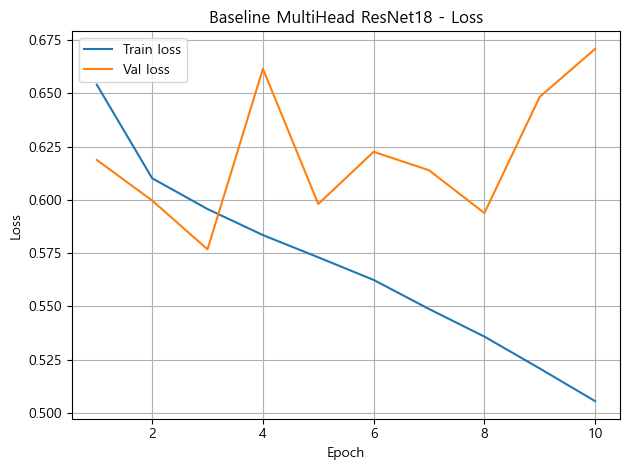

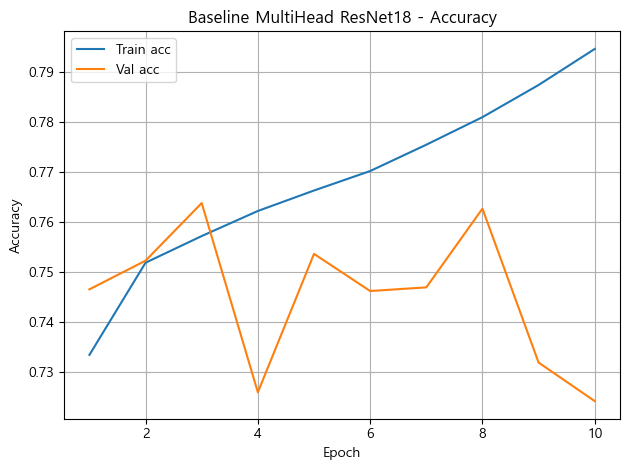

In [13]:
epochs = range(1, len(history["train_loss"]) + 1)

# 1) Loss 곡선
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline MultiHead ResNet18 - Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("docs/02.loss_curve.png", dpi=150)
plt.show()

# 2) Accuracy 곡선
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train acc")
plt.plot(epochs, history["val_acc"],   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline MultiHead ResNet18 - Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("docs/02.acc_curve.png", dpi=150)
plt.show()


In [14]:
import numpy as np

print("keys:", history.keys())
print("train_loss:", history["train_loss"])
print("val_loss:", history["val_loss"])
print("train_acc:", history["train_acc"])
print("val_acc:", history["val_acc"])
print("epoch_time_sec:", history["epoch_time_sec"])

best_idx = int(np.argmin(history["val_loss"]))
best_epoch = best_idx + 1

print(f"\n[Best epoch] {best_epoch}")
print(f"  train_loss={history['train_loss'][best_idx]:.4f}, train_acc={history['train_acc'][best_idx]:.4f}")
print(f"  val_loss={history['val_loss'][best_idx]:.4f},   val_acc={history['val_acc'][best_idx]:.4f}")

times = np.array(history["epoch_time_sec"])
print(f"\nEpoch times (sec): {times}")
print(f"Average epoch time: {times.mean():.1f} sec (~{times.mean()/60:.2f} min)")


keys: dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc', 'epoch_time_sec'])
train_loss: [0.6540236637395762, 0.610096835727458, 0.5956675259186656, 0.5834396571607049, 0.5730054122975375, 0.5623892980185727, 0.5487544785281318, 0.5358061834701513, 0.5208312490215427, 0.5055064916744764]
val_loss: [0.6186918366627069, 0.5996517537203437, 0.5767402836682436, 0.6615079237705821, 0.5980247252463323, 0.6225246153190196, 0.6138763181101442, 0.5937757593025096, 0.6483242298297468, 0.6708099408693566]
train_acc: [0.7333377719910832, 0.7518050541516246, 0.757141307135389, 0.7621643881556884, 0.7662652147323983, 0.7701663017103628, 0.7754384407488509, 0.7809621037264998, 0.787403089305794, 0.7946257718332643]
val_acc: [0.7464641321565965, 0.7522134532699706, 0.7637474541751528, 0.7258429508938674, 0.7535712265218375, 0.7461317605793166, 0.7468601493550577, 0.7626301199366372, 0.7317973523421588, 0.7240750169721657]
epoch_time_sec: [3324.92989020003, 3428.8950399000314, 3327.67688380001

In [15]:
import pandas as pd

df_hist = pd.DataFrame({
    "epoch": list(epochs),
    "train_loss": history["train_loss"],
    "train_acc":  history["train_acc"],
    "val_loss":   history["val_loss"],
    "val_acc":    history["val_acc"],
})

df_hist.to_csv("../data/processed/02.history.csv", index=False)
df_hist.head()


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.654024,0.733338,0.618692,0.746464
1,2,0.610097,0.751805,0.599652,0.752213
2,3,0.595668,0.757141,0.576740,0.763747
3,4,0.583440,0.762164,0.661508,0.725843
4,5,0.573005,0.766265,0.598025,0.753571


In [16]:
# 모델 가중치 저장 (baseline 버전)
torch.save(
    model.state_dict(),
    "models/02.resnet18_multhead_epoch10.pth"
)
